# Construcción de Red Neuronal (MLP)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="deep")

## 1. Carga de Datos Preprocesados

In [2]:
import os
# Cargamos directamente los datos procesados del notebook 01
data_path = 'outputs/01_processed_data.npz'
if not os.path.exists(data_path):
    raise FileNotFoundError("¡No se encontró el archivo de datos! Asegúrate de ejecutar el Notebook 01 primero.")

data = np.load(data_path, allow_pickle=True)
X = data['X_scaled']
y = data['y']

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (1200, 179)
Dimensiones de y: (1200,)


## 2. División de Datos (Train / Test)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Set de Prueba (Test): {X_test.shape[0]} muestras")

Set de Entrenamiento: 960 muestras
Set de Prueba (Test): 240 muestras


## 3. Entrenamiento de la Red Neuronal

In [4]:
# Arquitectura de 2 capas ocultas (100 neuronas, 50 neuronas)
print("Iniciando entrenamiento de la Red Neuronal...")
nn = MLPClassifier(hidden_layer_sizes=(100, 50), 
                   max_iter=500, 
                   activation='relu', 
                   solver='adam', 
                   random_state=42, 
                   early_stopping=True, 
                   n_iter_no_change=10)

nn.fit(X_train, y_train)
print(f"Entrenamiento completado en {nn.n_iter_} iteraciones.")

Iniciando entrenamiento de la Red Neuronal...
Entrenamiento completado en 12 iteraciones.


## 4. Evaluación de Precisión

In [5]:
# Predicciones
y_pred_train = nn.predict(X_train)
y_pred_test = nn.predict(X_test)

# Cálculo de precisión (Accuracy)
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"==========================================")
print(f"Precisión en Entrenamiento: {acc_train*100:.2f}%")
print(f"Precisión en Prueba (Test): {acc_test*100:.2f}%")
print(f"==========================================\n")

print("Reporte de Clasificación (Test):")
print(classification_report(y_test, y_pred_test))

Precisión en Entrenamiento: 91.88%
Precisión en Prueba (Test): 90.83%

Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       218
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00        11

    accuracy                           0.91       240
   macro avg       0.30      0.33      0.32       240
weighted avg       0.83      0.91      0.86       240



## 5. Matriz de Confusión

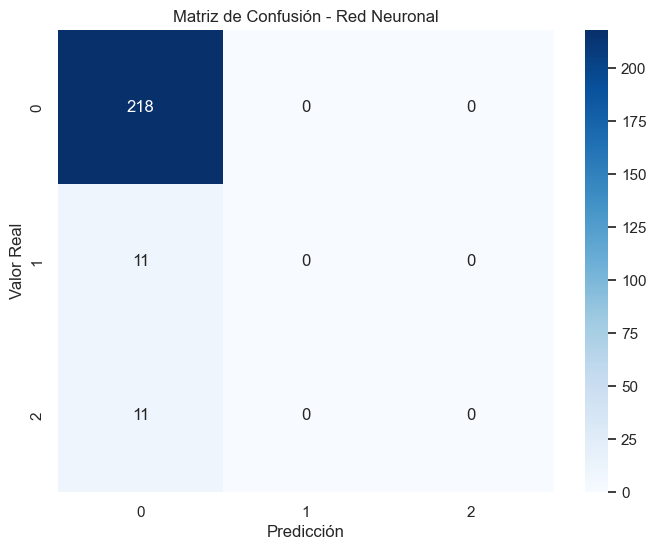

In [6]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Red Neuronal')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()